In [400]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [401]:
df = pd.read_csv(r'D:\arc-2025\arc\ai\Uddav-Rajbhandari\Logistic Regression\Files\spam_detection_dataset.csv')

In [402]:
df.head()

,num_links,num_words,has_offer,sender_score,all_caps,is_spam
0,3,98,1,0.718607,0,0
1,0,170,0,0.698901,1,0
2,0,38,0,0.620466,0,0
3,0,116,0,0.701755,0,0
4,3,89,1,0.583621,1,1


In [403]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   num_links     20000 non-null  int64  
 1   num_words     20000 non-null  int64  
 2   has_offer     20000 non-null  int64  
 3   sender_score  20000 non-null  float64
 4   all_caps      20000 non-null  int64  
 5   is_spam       20000 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 937.6 KB


In [404]:
df.describe(include='all')

,num_links,num_words,has_offer,sender_score,all_caps,is_spam
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,1.497300,109.506150,0.302750,0.694248,0.097800,0.09175
std,1.220478,51.969579,0.459459,0.188312,0.297051,0.28868
min,0.000000,20.000000,0.000000,0.000000,0.000000,0.00000
25%,1.000000,64.000000,0.000000,0.567073,0.000000,0.00000
50%,1.000000,110.000000,0.000000,0.699740,0.000000,0.00000
75%,2.000000,154.000000,1.000000,0.834083,0.000000,0.00000
max,9.000000,199.000000,1.000000,1.000000,1.000000,1.00000


In [405]:
df.isnull().sum()

num_links       0
num_words       0
has_offer       0
sender_score    0
all_caps        0
is_spam         0
dtype: int64

In [406]:
df.shape

(20000, 6)

In [407]:
# check if there are any duplicate rows
df.duplicated().sum()

402

In [408]:
duplicates = df[df.duplicated()]
print(duplicates.head())


      num_links  num_words  has_offer  sender_score  all_caps  is_spam
575           0        103          1           1.0         0        0
658           1        196          0           1.0         0        0
1449          1        100          1           1.0         0        0
1832          1        196          0           1.0         0        0
2035          1         37          0           1.0         0        0


In [409]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

In [410]:
print(df['is_spam'].value_counts())

is_spam
0    17765
1     1833
Name: count, dtype: int64


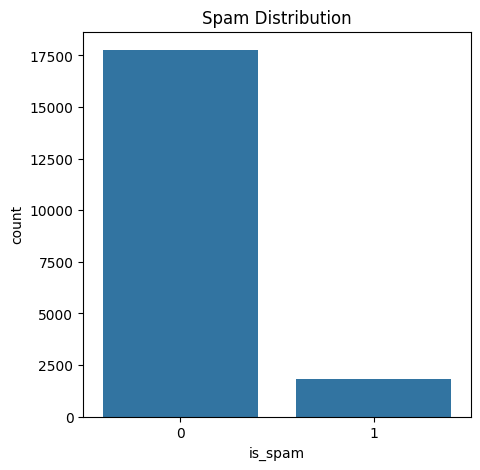

In [411]:
plt.figure(figsize=(5, 5))
sns.countplot(x='is_spam', data=df)
plt.title('Spam Distribution')
plt.show()

In [412]:
from sklearn.preprocessing import StandardScaler

numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_columns.remove('is_spam')  # Exclude target variable from scaling
def scale_numerical_features(df, numerical_columns):
    scaler = StandardScaler()
    df[numerical_columns] = scaler.fit_transform(df[numerical_columns])
    return df

df = scale_numerical_features(df,numerical_columns)

In [413]:
X = df.drop('is_spam',axis=1)
y = df['is_spam']

In [414]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)
# X, y = adasyn.fit_resample(X, y)



In [415]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

In [416]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [417]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.001, n_iters=1000 , lambda_=0.01):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.lambda_ = lambda_  # Regularization strength
        self.weights = None
        self.bias = None
        self.losses = []
         
    #Sigmoid method
    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    # def compute_loss(self, y_true, y_pred):
    #     # binary cross entropy
    #     epsilon = 1e-9
    #     y1 = y_true * np.log(y_pred + epsilon)
    #     y2 = (1-y_true) * np.log(1 - y_pred + epsilon)
    #     return -np.mean(y1 + y2)
    
    def compute_loss(self, y_true, y_pred):
        # Binary cross-entropy with L2 regularization
        epsilon = 1e-9
        y1 = y_true * np.log(y_pred + epsilon)
        y2 = (1 - y_true) * np.log(1 - y_pred + epsilon)
        cross_entropy = -np.mean(y1 + y2)
        l2_penalty = (self.lambda_ / 2) * np.sum(self.weights ** 2)
        return cross_entropy + l2_penalty

    def feed_forward(self,X):
        z = np.dot(X, self.weights) + self.bias
        A = self._sigmoid(z)
        return A

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # init parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # gradient descent
        for _ in range(self.n_iters):
            A = self.feed_forward(X)
            self.losses.append(self.compute_loss(y,A))
            dz = A - y # derivative of sigmoid and bce X.T*(A-y)
            # compute gradients
            dw = (1 / n_samples) * np.dot(X.T, dz)
            db = (1 / n_samples) * np.sum(dz)
            # update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
    def predict(self, X):
        threshold = .5
        y_hat = np.dot(X, self.weights) + self.bias
        y_predicted = self._sigmoid(y_hat)
        y_predicted_cls = [1 if i > threshold else 0 for i in y_predicted]
        
        return np.array(y_predicted_cls)
    
    def accuracy(self,y, y_hat):
        accuracy = np.sum(y == y_hat) / len(y)
        return accuracy
    
    def precision(self, y, y_hat):
        true_positive = np.sum((y == 1) & (y_hat == 1))
        false_positive = np.sum((y == 0) & (y_hat == 1))
        precision = true_positive / (true_positive + false_positive + 1e-9)
        return precision
    
    def recall(self, y, y_hat):
        true_positive = np.sum((y == 1) & (y_hat == 1))
        false_negative = np.sum((y == 1) & (y_hat == 0))
        recall = true_positive / (true_positive + false_negative + 1e-9)
        return recall
    
    def f1_score(self, y, y_hat):
        precision = self.precision(y, y_hat)
        recall = self.recall(y, y_hat)
        f1 = 2 * (precision * recall) / (precision + recall + 1e-9)
        return f1

In [418]:
from sklearn.metrics import confusion_matrix, classification_report
# Fit the model
regressor = LogisticRegressionScratch(learning_rate=0.01, n_iters=1000 , lambda_=0.1)
regressor.fit(X_train, y_train)

# Predict
predictions = regressor.predict(X_test)

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)

# Accuracy
accuracy = regressor.accuracy(y_test, predictions)
print("Test accuracy: {:.3f}".format(accuracy))


precision = regressor.precision(y_test, predictions)
print("Test precision: {:.3f}".format(precision))

recall = regressor.recall(y_test, predictions)
print("Test recall: {:.3f}".format(recall))

f1_score = regressor.f1_score(y_test, predictions)
print("Test f1_score: {:.3f}".format(f1_score))

Confusion Matrix:
 [[2731  843]
 [ 170 3362]]
Test accuracy: 0.857
Test precision: 0.800
Test recall: 0.952
Test f1_score: 0.869


In [419]:
print("Classification Report:\n", classification_report(y_test, predictions))

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.76      0.84      3574
           1       0.80      0.95      0.87      3532

    accuracy                           0.86      7106
   macro avg       0.87      0.86      0.86      7106
weighted avg       0.87      0.86      0.86      7106



Accuracy: 0.8753166338305657


Precision: 0.8614754098360655
Recall: 0.8926953567383918
F1-score: 0.8768075639599555


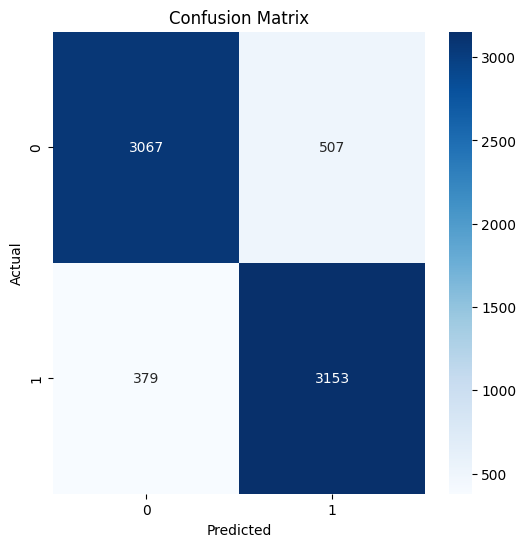

              precision    recall  f1-score   support

           0       0.89      0.86      0.87      3574
           1       0.86      0.89      0.88      3532

    accuracy                           0.88      7106
   macro avg       0.88      0.88      0.88      7106
weighted avg       0.88      0.88      0.88      7106



In [420]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


model = LogisticRegression(max_iter=1000, random_state=42,penalty='l2') 
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred))

Positive class ratio in test set: 0.50


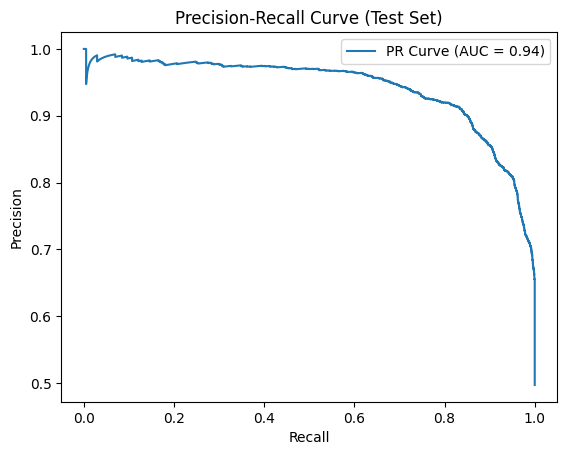

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Assuming you have: y_test (true labels), y_probs (predicted probabilities for the positive class)

# Check class distribution
class_ratio = sum(y_test) / len(y_test)  # Ratio of positive class
print(f"Positive class ratio in test set: {class_ratio:.2f}")
y_prob = model.predict_proba(X_test)[:, 1]  # Get probabilities for the positive class
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test Set)')
plt.legend()
plt.show()

In [424]:
X = df.drop('is_spam', axis=1)
y = df['is_spam']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_with_imbalanced_data = LogisticRegression(max_iter=1000, random_state=42,penalty='l2')
model_with_imbalanced_data.fit(X_train, y_train)
y_pred = model_with_imbalanced_data.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Accuracy:

 0.9415816326530613
Precision: 0.805668016194332
Recall: 0.5236842105263158
F1-score: 0.634768740031898
Confusion Matrix:
 [[3492   48]
 [ 181  199]]


Positive class ratio in test set: 0.10


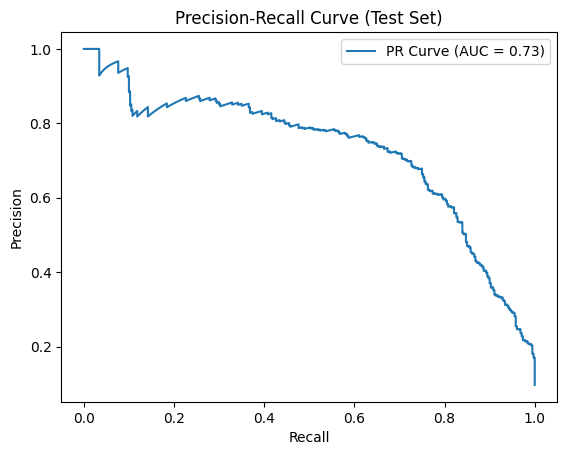

In [426]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Assuming you have: y_test (true labels), y_probs (predicted probabilities for the positive class)

# Check class distribution
class_ratio = sum(y_test) / len(y_test)  # Ratio of positive class
print(f"Positive class ratio in test set: {class_ratio:.2f}")

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test Set)')
plt.legend()
plt.show()

## when to chose metrices
| Metric        | Use When...                                                      | Example                                   |
| ------------- | ---------------------------------------------------------------- | ----------------------------------------- |
| **Precision** | **False positives are costly.** You want correct positives.      | Spam detection (minimize false alarms).   |
| **Recall**    | **False negatives are costly.** You want to catch all positives. | Cancer detection (minimize missed cases). |
| **F1 Score**  | Balance precision and recall.                                    | General classification with trade-offs.   |